In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
sys.path.append('..')

import utilities.functions as functions


from utilities.functions import (
    summary,
    gerar_resumo_decis,
    resumo_coorte_ativa
 )
from utilities.graficos import (
  boxplot_meses
 
)
from utilities.outliers import(
    outlier_method,
    mark_outliers_iqr_zscore_mad
)
from pathlib import Path
BASE_PATH = Path("/Users/maceli/ifood_cs/dados") 


In [2]:
df = pd.read_parquet(BASE_PATH / "gold" / "df_publico.parquet")
df.head()

,customer_id,is_target,active,created_at,delivery_address_state,merchant_id,order_created_at,order_id,order_total_amount,origin_platform,order_created_month,unique_order_hash,weekday,hour,day,total_amount_mes,ticket_medio,num_pedidos_mes,num_pedidos_hist
0,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,e80a8d7a13b52ca9ccf247ca3396f1018be41a5b014d79...,2019-01-11 14:07:48+00:00,c9a236fc0b0255433d0852dc90ef8b9949f3a3ab67e553...,10.0,ANDROID,1,3171095530380566075,Friday,14,11,206.5,12.147059,17,19
1,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-05 13:38:28+00:00,db3b910b374ce240d551b829b297b9547f4e2feee9fd78...,12.0,ANDROID,1,14445504651562908569,Saturday,13,5,206.5,12.147059,17,19
2,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-13 13:50:06+00:00,a20903719abdaae9f6639681845f95963de83e0047ff13...,13.0,ANDROID,1,16546632448525009961,Sunday,13,13,206.5,12.147059,17,19
3,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-26 13:15:53+00:00,90652cc196fbfa352b1d4d61b18b5babf39fad949c7ccc...,13.0,ANDROID,1,16333679914791111686,Saturday,13,26,206.5,12.147059,17,19
4,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-15 13:48:33+00:00,9091a0ead77e2ed0d5ed9ce6787631386bd120036ff5b7...,13.0,ANDROID,1,6333204433002785330,Tuesday,13,15,206.5,12.147059,17,19


In [3]:
id_both_monht=df[df['order_created_month']==12]['customer_id'].unique()
df = df[df['customer_id'].isin(id_both_monht)].reset_index(drop=True)


In [4]:
df_stats_mes = df.groupby(['order_created_month', 'is_target'])['order_total_amount'].agg(
    Média=('mean'),
    Mediana=('median'),
    Mínimo=('min'),
    Máximo=('max'),
    Desvio_Padrão=('std')
).round(2)
df_stats_mes['cv'] = (df_stats_mes['Desvio_Padrão'] / df_stats_mes['Média']).round(3)
df_stats_mes

Média  Mediana  Mínimo    Máximo  \
order_created_month is_target                                     
1                   control    48.02     39.9     0.0  138750.9   
                    target     47.91     39.9     0.0    5226.0   
12                  control    47.86     39.8     0.0  138750.9   
                    target     47.60     39.8     0.0    5226.0   

                               Desvio_Padrão     cv  
order_created_month is_target                        
1                   control           155.32  3.234  
                    target             35.61  0.743  
12                  control           197.00  4.116  
                    target             36.04  0.757

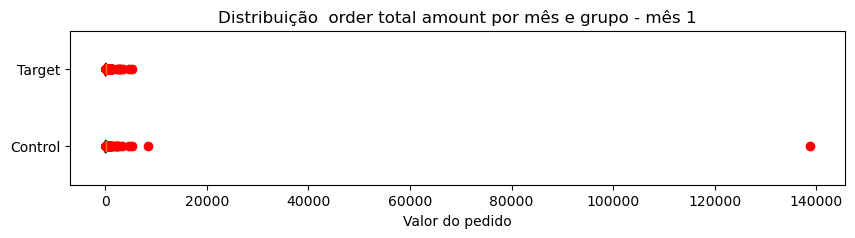

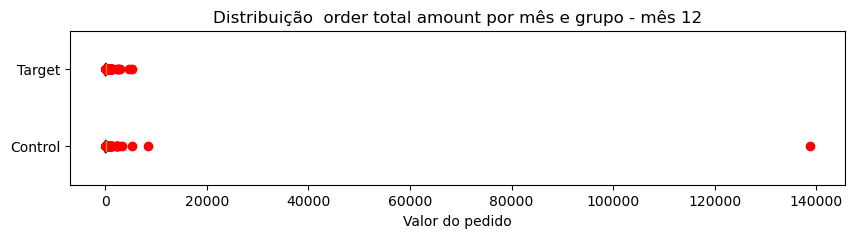

In [5]:
boxplot_meses(df, [1, 12])

In [6]:
outlier_method(df,var='order_total_amount')

Use MAD (assimétrico + robusto)


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 3293704.
  res = hypotest_fun_out(*samples, **kwds)


'mad'

In [7]:
df = mark_outliers_iqr_zscore_mad(df)


In [9]:
total_amount = df.groupby(['order_created_month','outlier_iqr','outlier_zscore','outlier_mad']).agg(
    total_pedidos=('unique_order_hash', 'nunique')
).round(2)
total_amount

total_pedidos
order_created_month outlier_iqr outlier_zscore outlier_mad               
1                   False       False          False              1941774
                    True        False          False                33897
                                               True                 63761
                                True           True                 19812
12                  False       False          False              1162638
                    True        False          False                22519
                                               True                 38131
                                True           True                 11172

In [17]:
df_outliers = df[
    df['outlier_iqr'] & 
    df['outlier_zscore'] & 
    df['outlier_mad']][['customer_id','order_created_month','order_total_amount','num_pedidos_hist','num_pedidos_mes']]
len(df_outliers)


30984

In [18]:
df_outliers.head()

,customer_id,order_created_month,order_total_amount,num_pedidos_hist,num_pedidos_mes
252,298bdef443cf4dd3614cffa088a939fa3d3ebad163d220...,1,163.0,14,8
580,3e4e88a5858dbd9ec7df8ccdb30a81d93c8d9152f5c94c...,1,192.7,3,2
581,3e4e88a5858dbd9ec7df8ccdb30a81d93c8d9152f5c94c...,12,192.7,3,1
1226,275ebdcc9e8c1f9bac3f64695cb9699eb97ce56303a246...,1,199.5,14,7
1233,275ebdcc9e8c1f9bac3f64695cb9699eb97ce56303a246...,12,199.5,14,7


In [12]:
p99 = df['order_total_amount'].quantile(0.99)

acima_p99 = df[
    df['order_total_amount'] > p99
]

acima_p99[['customer_id','unique_order_hash','order_created_month','order_total_amount','outlier_iqr','outlier_zscore','outlier_mad']]

acima_p99['customer_id'].nunique()

13840

In [13]:
id_p99=acima_p99['customer_id'].unique()

In [14]:
df['id_p99'] = df['customer_id'].isin(id_p99).astype(int)
df[df['id_p99']==1][['customer_id','unique_order_hash','order_created_month','order_total_amount','day','outlier_iqr','outlier_zscore','outlier_mad','id_p99']].head(10)

,customer_id,unique_order_hash,order_created_month,order_total_amount,day,outlier_iqr,outlier_zscore,outlier_mad,id_p99
131,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,6280395930853013257,1,47.00,26,False,False,False,1
132,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,8375403443903045600,1,81.70,23,False,False,False,1
133,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,4965369037086780196,1,69.40,22,False,False,False,1
134,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,13526963463313600868,1,112.50,25,True,False,False,1
135,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,7409692391608107439,1,195.00,28,True,False,True,1
136,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,12290574871276594958,1,168.00,5,True,False,True,1
137,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,9828447071624588389,1,44.72,22,False,False,False,1
138,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,5766135708987893934,12,168.00,6,True,False,True,1
139,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,16693794814942610970,12,44.72,23,False,False,False,1
579,3e4e88a5858dbd9ec7df8ccdb30a81d93c8d9152f5c94c...,8097370571800108249,1,91.50,30,False,False,False,1


In [15]:
stats_p99_por_cliente = (
    df[df['id_p99'] == 1]
    .groupby(['customer_id','order_created_month','is_target'])['order_total_amount']
    .agg(
        total_transacoes='count',
        minimo='min',
        maximo='max',
        media='mean'
    )
    .reset_index()   # ISSO resolve seu problema
    .sort_values(by=['customer_id','total_transacoes'], ascending=[False,False])
)

stats_p99_por_cliente.head(10)




,customer_id,order_created_month,is_target,total_transacoes,minimo,maximo,media
27678,fff9bafcd57a1c84363543ade6f8221b5dee4f1cc9e3f6...,1,target,16,32.88,217.40,103.711250
27679,fff9bafcd57a1c84363543ade6f8221b5dee4f1cc9e3f6...,12,target,9,32.88,183.60,97.720000
27676,fff58fc98d53b8fc0645246ca49bfb4e3751ac61750314...,1,target,8,49.00,203.00,102.825000
27677,fff58fc98d53b8fc0645246ca49bfb4e3751ac61750314...,12,target,3,62.00,203.00,130.500000
27674,fff38c58e3e9127d626e524dc563bd5142151969b8aac1...,1,target,11,49.90,181.00,90.963636
27675,fff38c58e3e9127d626e524dc563bd5142151969b8aac1...,12,target,2,64.30,146.50,105.400000
27672,ffdc0a7fd869aae82d38b44465315dd1aed2caaac5d502...,1,control,1,334.48,334.48,334.480000
27673,ffdc0a7fd869aae82d38b44465315dd1aed2caaac5d502...,12,control,1,334.48,334.48,334.480000
27670,ffda9f7e97ca520dd8f775aab87601d7a3a75c1dd58491...,1,control,14,16.00,181.40,68.578571
27671,ffda9f7e97ca520dd8f775aab87601d7a3a75c1dd58491...,12,control,2,31.10,76.70,53.900000


In [19]:
p10 = df['order_total_amount'].quantile(0.10)

abaixo_p10 = df[
    df['order_total_amount'] < p10
]

abaixo_p10[['customer_id','unique_order_hash','order_created_month','order_total_amount','outlier_iqr','outlier_zscore','outlier_mad']]

abaixo_p10['customer_id'].unique()


array(['755e1fa18f25caec5edffb188b13fd844b2af8cf5adedcf77c028f36cb9382ea',
       '2c793590086a05d39f1fdf9513f585dd7ca6d2ba404bb40248d3102e024920b2',
       '2c2c1ec8e79d1b98e67aaefb39b477dd9c95bea6e498c8ff2ae610cbddd0cc17',
       ...,
       '5e18564d34ceb2f0a24396b8c58fd1b09ff2528c396262bd9aa7ca1420ad88b3',
       'a8961e837d133f217d29e31014ae8f2a863453914ba4f2829555977aeaae2177',
       'd7022ecde8133cf221a3de98107d100d78c851650a64c010d483a5b241a25b0f'],
      dtype=object)

In [ ]:
id_p10=abaixo_p10['customer_id'].unique()
df['id_p10'] = df['customer_id'].isin(id_p10).astype(int)
df[df['id_p10']==1][['customer_id','unique_order_hash','order_created_month','order_total_amount','day','outlier_iqr','outlier_zscore','outlier_mad','id_p99']].head(10)
stats_p10_por_cliente = (
    df[df['id_p10'] == 1]
    .groupby(['customer_id','order_created_month','is_target'])['order_total_amount']
    .agg(
        total_transacoes='count',
        minimo='min',
        maximo='max',
        media='mean'
    )
    .reset_index()   
    .sort_values(by=['customer_id','total_transacoes'], ascending=[False,False])
)
stats_p10_por_cliente.head(10)

,customer_id,order_created_month,is_target,total_transacoes,minimo,maximo,media
212202,ffffd512938c9c6a7fc101b6bc044c2bc542505ceff2a5...,1,control,6,10.00,48.1,31.233333
212203,ffffd512938c9c6a7fc101b6bc044c2bc542505ceff2a5...,12,control,2,16.00,37.3,26.650000
212200,ffffb914ed2fc2abf0763d8ffeb2a6f6a4149d48b71897...,1,target,8,9.00,29.0,21.250000
212201,ffffb914ed2fc2abf0763d8ffeb2a6f6a4149d48b71897...,12,target,5,9.00,29.0,19.400000
212198,ffffb54b6362e4b0eb7f22ca3695fbd1c14865e0d4b42d...,1,target,2,9.00,10.0,9.500000
212199,ffffb54b6362e4b0eb7f22ca3695fbd1c14865e0d4b42d...,12,target,1,9.00,9.0,9.000000
212196,ffff5347ec344619920c4ff44449dfd1a34e41c24bd77d...,1,control,13,12.01,88.4,43.232308
212197,ffff5347ec344619920c4ff44449dfd1a34e41c24bd77d...,12,control,7,12.01,59.8,33.217143
212194,fffe7b38b14ac2fca8906500fbecf87f5f8470179ed7ff...,1,control,11,8.00,138.7,74.290909
212195,fffe7b38b14ac2fca8906500fbecf87f5f8470179ed7ff...,12,control,7,21.00,138.7,85.100000


In [21]:
df.head()

,customer_id,is_target,active,created_at,delivery_address_state,merchant_id,order_created_at,order_id,order_total_amount,origin_platform,...,num_pedidos_hist,outlier_iqr,outlier_zscore,outlier_mad,lim_inf_iqr,lim_sup_iqr,zscore,mad_score,id_p99,id_p10
0,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,e80a8d7a13b52ca9ccf247ca3396f1018be41a5b014d79...,2019-01-11 14:07:48+00:00,c9a236fc0b0255433d0852dc90ef8b9949f3a3ab67e553...,10.0,ANDROID,...,19,False,False,False,0.01,104.1,-1.064365,-1.362672,0,1
1,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-05 13:38:28+00:00,db3b910b374ce240d551b829b297b9547f4e2feee9fd78...,12.0,ANDROID,...,19,False,False,False,0.01,104.1,-1.008208,-1.271524,0,1
2,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-13 13:50:06+00:00,a20903719abdaae9f6639681845f95963de83e0047ff13...,13.0,ANDROID,...,19,False,False,False,0.01,104.1,-0.980130,-1.225949,0,1
3,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-26 13:15:53+00:00,90652cc196fbfa352b1d4d61b18b5babf39fad949c7ccc...,13.0,ANDROID,...,19,False,False,False,0.01,104.1,-0.980130,-1.225949,0,1
4,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-15 13:48:33+00:00,9091a0ead77e2ed0d5ed9ce6787631386bd120036ff5b7...,13.0,ANDROID,...,19,False,False,False,0.01,104.1,-0.980130,-1.225949,0,1


In [22]:
df.to_parquet(BASE_PATH / "gold" / "df_publico.parquet", index=False)

In [ ]:
# Calcular LTV histórico E total de pedidos
historico_cliente = df[df['customer_id'] == '002ca070253de5dd983f577e0156dae30cfe981198bce5c7815755748343594c']

ltv_historico = historico_cliente['order_total_amount'].sum()
total_pedidos = len(historico_cliente)
tempo_atividade = (historico_cliente['order_created_at'].max() - historico_cliente['order_created_at'].min()).days

# Calcular métricas derivadas
ticket_medio = ltv_historico / total_pedidos if total_pedidos > 0 else 0

# LTV mensal projetado
if tempo_atividade > 0:
    ltv_mensal = (ltv_historico / tempo_atividade) * 30
    ltv_anual_projetado = ltv_mensal * 12
    frequencia_mensal = (total_pedidos / tempo_atividade) * 30
else:
    ltv_anual_projetado = ltv_historico * 4
    frequencia_mensal = total_pedidos

print("📊 ANÁLISE COMPLETA DO CLIENTE:")
print(f"💰 LTV Histórico: R$ {ltv_historico:.2f}")
print(f"🛒 Total de Pedidos: {total_pedidos}")
print(f"📈 LTV Anual Projetado: R$ {ltv_anual_projetado:.2f}")
print(f"💵 Ticket Médio: R$ {ticket_medio:.2f}")
print(f"📅 Frequência Mensal: {frequencia_mensal:.1f} pedidos/mês")
print(f"⏰ Tempo de Atividade: {tempo_atividade} dias")

# Análise adicional
if total_pedidos > 0:
    print(f"\n🎯 MÉTRICAS AVANÇADAS:")
    print(f"• Valor por Dia: R$ {ltv_historico/tempo_atividade:.2f}" if tempo_atividade > 0 else "• Valor por Dia: N/A")
    print(f"• Pedidos por Dia: {total_pedidos/tempo_atividade:.3f}" if tempo_atividade > 0 else "• Pedidos por Dia: N/A")
    
    # Classificação do cliente
    if ltv_anual_projetado > 5000:
        classificacao = "💎 CLIENTE PREMIUM"
    elif ltv_anual_projetado > 2000:
        classificacao = "🥇 CLIENTE OURO" 
    elif ltv_anual_projetado > 1000:
        classificacao = "🥈 CLIENTE PRATA"
    else:
        classificacao = "👤 CLIENTE BÁSICO"
    
    print(f"• Classificação: {classificacao}")
